<a href="https://colab.research.google.com/github/ernishantsharma4u-beep/deep-neural-assignment_1/blob/main/2025ag05585_rnn_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BITS ID: 2025AG05585

Name: NISHANT SHARMA

Email: 2025ag05585@wilp.bits-pilani.ac.in

Date: 25-04-2026

In [11]:
## 1.1 Import Libraries

import os
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import json
import math

In [12]:
#1.2Data Loading
!pip install kagglehub

In [13]:
# 1.2: Data path download
import kagglehub

# Download latest version
data_path = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")

print("Path to dataset files:", data_path)

Using Colab cache for faster access to the 'electric-power-consumption-data-set' dataset.
Path to dataset files: /kaggle/input/electric-power-consumption-data-set


In [66]:
# 1.3Basic Metadata Information
# Load the dataset into a DataFrame
file_path = os.path.join(data_path, 'household_power_consumption.txt')
df = pd.read_csv(file_path, sep=';', low_memory=False)

# Ensure datetime exists
df['Date Time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                format='%d/%m/%Y %H:%M:%S',
                                errors='coerce')

# Reduced time step to 1000
df = df.iloc[:1000].copy()

# Replace missing symbols
df.replace("", pd.NA, inplace=True)

# Convert target column 'Global_active_power' to numeric
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

# Assign target variable
target = df["Global_active_power"]

# -------------------------------
# Metadata
# -------------------------------
print("Dataset Name      : Individual Household Electric Power Consumption")
print("Problem Type      : Univariate Time Series Forecasting")
print("Target Variable   : Global_active_power")

print("\nShape             :", df.shape)
print("Number of Features:", df.shape[1])
print("Number of Records :", len(df))

print("\nDate Range        :", df['Date Time'].min(), "→", df['Date Time'].max())

print("\nMissing Values    :", df['Global_active_power'].isna().sum())

print("\nSampling Frequency: 1-minute interval")

print("\nData Type Summary:")

print(df.dtypes)

# Define metric_justification, dataset_name, dataset_source, problem_type, primary_metric
metric_justification = "RMSE penalizes larger prediction errors more strongly due to squaring, which is important for active power forecasting where large deviations are critical. Unlike MAPE, RMSE is unaffected by near-zero or negative temperature values."
print(f"\n Metric Justification : {metric_justification}")

dataset_name = "Individual Household Electric Power Consumption"
problem_type = "Univariate Time Series Forecasting"
primary_metric = "RMSE"
dataset_source = "uciml/electric-power-consumption-data-set" # Extracted from cell urotUXd1i46R: data_path = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")

Dataset Name      : Individual Household Electric Power Consumption
Problem Type      : Univariate Time Series Forecasting
Target Variable   : Global_active_power

Shape             : (1000, 10)
Number of Features: 10
Number of Records : 1000

Date Range        : 2006-12-16 17:24:00 → 2006-12-17 10:03:00

Missing Values    : 0

Sampling Frequency: 1-minute interval

Data Type Summary:
Date                             object
Time                             object
Global_active_power             float64
Global_reactive_power            object
Voltage                          object
Global_intensity                 object
Sub_metering_1                   object
Sub_metering_2                   object
Sub_metering_3                  float64
Date Time                datetime64[ns]
dtype: object

 Metric Justification : RMSE penalizes larger prediction errors more strongly due to squaring, which is important for active power forecasting where large deviations are critical. Unlike MAPE, RMSE

Shape         : (1000, 10)
Date range    : 2006-12-16 17:24:00 → 2006-12-17 10:03:00
Missing values: 0

Global Active Power stats:
count    1000.000000
mean        2.418772
std         1.239979
min         0.206000
25%         1.806000
50%         2.414000
75%         3.308000
max         7.706000
Name: Global_active_power, dtype: float64


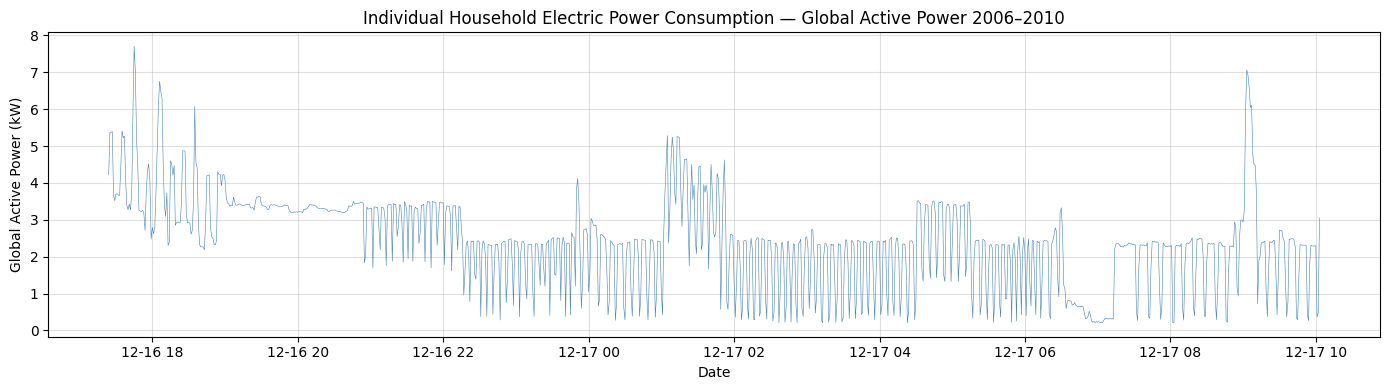

In [16]:
## 1.4 Exploratory Data Analysis

# df['Date Time'] is already parsed from cell 50Z9-muAjAmh and is of type datetime64[ns]
# Re-parsing it is unnecessary and the format was incorrect.
df = df.sort_values('Date Time').reset_index(drop=True)

print("Shape         :", df.shape)
print("Date range    :", df['Date Time'].min(), "→", df['Date Time'].max())
print("Missing values:", df['Global_active_power'].isna().sum()) # Changed column name
print("\nGlobal Active Power stats:") # Changed label
print(df['Global_active_power'].describe()) # Changed column name

# Full time series
plt.figure(figsize=(14, 4))
plt.plot(df['Date Time'], df['Global_active_power'], color='steelblue', linewidth=0.4) # Changed column name
plt.title("Individual Household Electric Power Consumption — Global Active Power 2006–2010") # Changed title
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)") # Changed label
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

#1.5 Data Preprocessing

In [17]:
# converting any string into numerical value for Target variable
# handling any missing value
df["Global_active_power"] = pd.to_numeric(
    df["Global_active_power"],
    errors="coerce"
)

df["Global_active_power"] = df["Global_active_power"].fillna(method="ffill")
df["Global_active_power"] = df["Global_active_power"].fillna(method="bfill")
print(" the null value is ",df["Global_active_power"].isna().sum())

target = df["Global_active_power"].values

 the null value is  0


/tmp/ipykernel_19816/3429168023.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["Global_active_power"] = df["Global_active_power"].fillna(method="ffill")
/tmp/ipykernel_19816/3429168023.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["Global_active_power"] = df["Global_active_power"].fillna(method="bfill")


In [19]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ------------------------------------------
# Preprocess Time Series Data
# ------------------------------------------
def preprocess_timeseries(data):
    """
    Args:
        data : raw Global_active_power column

    Returns:
        processed_data, scaler
    """

    # Convert to numeric
    data = pd.to_numeric(data, errors='coerce')

    # Handle missing values
    data = data.fillna(method='ffill')
    data = data.fillna(method='bfill')

    # Convert to DataFrame
    data = pd.DataFrame(data)

    # Normalize to [0,1]
    scaler = MinMaxScaler()
    processed_data = scaler.fit_transform(data)

    return processed_data, scaler


# ------------------------------------------
# Create Sequences
# ------------------------------------------
def create_sequences(data, seq_length, pred_horizon):
    """
    Input  : past seq_length values
    Output : next pred_horizon values
    """

    X = []
    y = []

    for i in range(len(data) - seq_length - pred_horizon + 1):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length:i + seq_length + pred_horizon, 0])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y


# ==========================================
# Use Exact Target Variable
# ==========================================
target = df["Global_active_power"]

# ------------------------------------------
# Parameters
# ------------------------------------------
seq_length = 24       # Lookback window
pred_horizon = 1      # Predict next step

# ------------------------------------------
# Run Preprocessing
# ------------------------------------------
processed_data, scaler = preprocess_timeseries(target)

X, y = create_sequences(
    processed_data,
    seq_length,
    pred_horizon
)

# ------------------------------------------
# REQUIRED Temporal Train/Test Split
# ------------------------------------------
split_index = int(len(X) * 0.90)   # 90/10 split

X_train = X[:split_index]
X_test  = X[split_index:]

y_train = y[:split_index]
y_test  = y[split_index:]

# ------------------------------------------
# Report
# ------------------------------------------
train_test_ratio = "90/10"
train_samples = len(X_train)
test_samples = len(X_test)

print("\nTrain/Test Split:", train_test_ratio)
print("Training Samples:", train_samples)
print("Test Samples    :", test_samples)
print("IMPORTANT: Temporal split used (NO shuffling)")

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

# ------------------------------------------
# Verify No NaN Values
# ------------------------------------------
print("\nNaN Check:")
print("X_train:", np.isnan(X_train).sum())
print("y_train:", np.isnan(y_train).sum())
print("X_test :", np.isnan(X_test).sum())
print("y_test :", np.isnan(y_test).sum())


Train/Test Split: 90/10
Training Samples: 878
Test Samples    : 98
IMPORTANT: Temporal split used (NO shuffling)

X_train shape: (878, 24, 1)
X_test shape : (98, 24, 1)
y_train shape: (878, 1)
y_test shape : (98, 1)

NaN Check:
X_train: 0
y_train: 0
X_test : 0
y_test : 0


/tmp/ipykernel_19816/3220181485.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')
/tmp/ipykernel_19816/3220181485.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='bfill')


In [20]:
# Select target feature: Global_active_power
data = df[['Global_active_power']].values

# REQUIRED: Temporal split — NO shuffling
split_idx = int(len(data) * 0.9)
train_data = data[:split_idx]
test_data  = data[split_idx:]

train_test_ratio = "90/10"

# Normalize using StandardScaler (fit on train only)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

print("TEMPORAL SPLIT (no shuffling)")
print(f"Total samples  : {len(data)}")
print(f"Train samples  : {len(train_data)}")
print(f"Test samples   : {len(test_data)}")
print(f"Split ratio    : {train_test_ratio}")

TEMPORAL SPLIT (no shuffling)
Total samples  : 1000
Train samples  : 900
Test samples   : 100
Split ratio    : 90/10


In [21]:
seq_length = 20  # Number of past time steps to use as input
pred_horizon = 1 # Number of future time steps to predict

def create_sequences(data, seq_length, horizon):
    """Create sliding-window sequences for time series prediction."""
    X, y = [], []
    for i in range(len(data) - seq_length - horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length : i + seq_length + horizon])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, seq_length, pred_horizon)
X_test,  y_test  = create_sequences(test_scaled,  seq_length, pred_horizon)

train_samples = len(X_train)
test_samples  = len(X_test)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")
print("sequence length is:", seq_length)
print("prediction horizon is:", pred_horizon)

X_train: (880, 20, 1)  y_train: (880, 1, 1)
X_test : (80, 20, 1)   y_test : (80, 1, 1)
sequence length is: 20
prediction horizon is: 1


#PART 2: LSTM/GRU IMPLEMENTATION

In [22]:
## 2.1 Build RNN Model (LSTM with ≥2 stacked layers)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam

def build_rnn_model(input_shape, hidden_units, output_size):
    """Build stacked LSTM model (≥2 recurrent layers)."""
    model = Sequential([
        Input(shape=input_shape),
        LSTM(hidden_units, return_sequences=True),   # Layer 1
        LSTM(hidden_units // 2, return_sequences=False),  # Layer 2
        Dense(output_size)
    ])
    return model

n_features = 1 # Define n_features for univariate time series

rnn_model = build_rnn_model(
    input_shape=(seq_length, n_features),
    hidden_units=64,
    output_size=pred_horizon
)

rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
## 2.2 Train RNN Model

from tensorflow.keras.callbacks import EarlyStopping

print("RNN MODEL TRAINING")

early_stop_rnn = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

rnn_start_time = time.time()

history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_rnn],
    verbose=1
)

rnn_training_time = time.time() - rnn_start_time

actual_epochs_rnn = len(history_rnn.history['loss'])

# Track initial and final loss
initial_loss_rnn = history_rnn.history['loss'][0]
final_loss_rnn   = history_rnn.history['loss'][-1]
reduction_rnn    = ((initial_loss_rnn - final_loss_rnn) / initial_loss_rnn) * 100

print(f"\nTraining completed in {rnn_training_time:.2f} seconds")
print(f"Epochs run          : {actual_epochs_rnn}/50 (early stopping)")
print(f"RNN Initial Loss    : {initial_loss_rnn:.6f}")
print(f"RNN Final Loss      : {final_loss_rnn:.6f}")
print(f"RNN Loss Reduction  : {reduction_rnn:.2f}%")

RNN MODEL TRAINING
Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.6883 - mae: 0.6404 - val_loss: 1.4868 - val_mae: 0.9172
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.5399 - mae: 0.5846 - val_loss: 1.4424 - val_mae: 0.9203
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.5384 - mae: 0.5807 - val_loss: 1.3813 - val_mae: 0.8874
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.5257 - mae: 0.5770 - val_loss: 1.3461 - val_mae: 0.8866
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.5248 - mae: 0.5709 - val_loss: 1.3329 - val_mae: 0.8846
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.5185 - mae: 0.5631 - val_loss: 1.3296 - val_mae: 0.9080
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.5102 - mae: 0.5625 - val_loss: 1.2697 - val_mae: 0.8574
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.5162 - mae: 0.5667 - val_loss: 1.2895 - val_mae: 0.8771
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms

In [24]:
## 2.3 Evaluate RNN Model

def calculate_mape(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    mask = np.abs(y_true) >= 0.1          # exclude near-zero true values
    if mask.sum() == 0:
        return float('nan')
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Predictions & inverse transform
preds_rnn_scaled = rnn_model.predict(X_test)
preds_rnn = scaler.inverse_transform(preds_rnn_scaled.reshape(-1, 1))
y_true    = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_rnn  = mean_absolute_error(y_true, preds_rnn)
rmse_rnn = np.sqrt(mean_squared_error(y_true, preds_rnn))
mape_rnn = calculate_mape(y_true, preds_rnn)
r2_rnn   = r2_score(y_true, preds_rnn)

print("\nRNN Model Performance:")
print(f"  MAE      : {mae_rnn:.4f}")
print(f"  RMSE     : {rmse_rnn:.4f}")
print(f"  MAPE     : {mape_rnn:.4f}%")
print(f"  R² Score : {r2_rnn:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step

RNN Model Performance:
  MAE      : 0.6362
  RMSE     : 0.8972
  MAPE     : 59.4510%
  R² Score : 0.6444


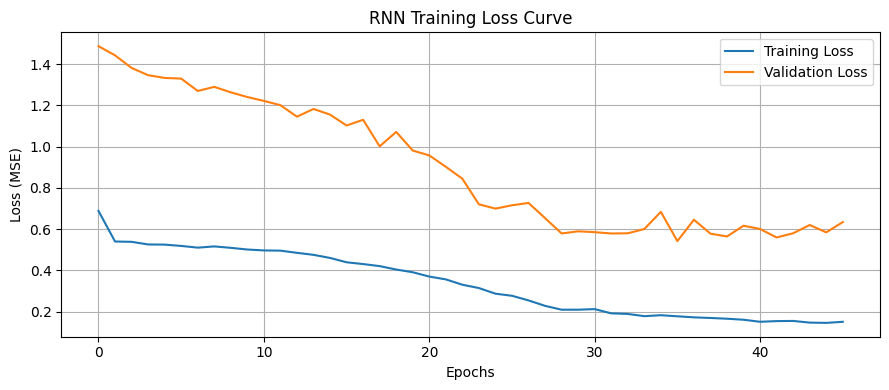

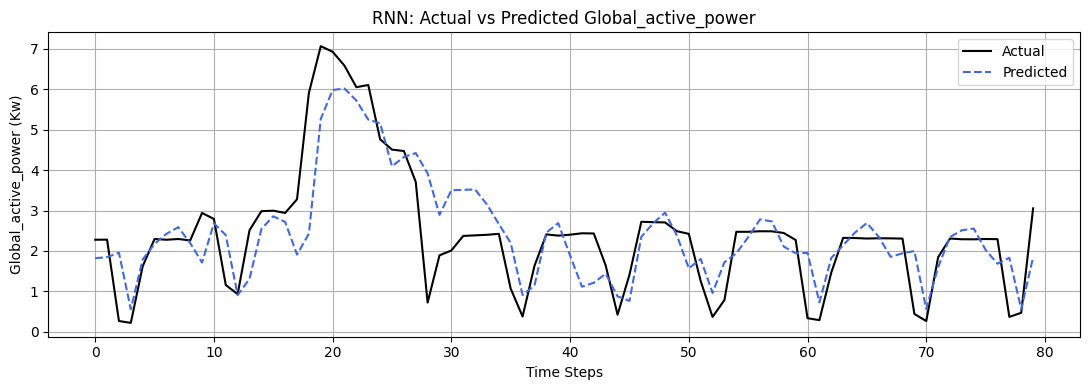

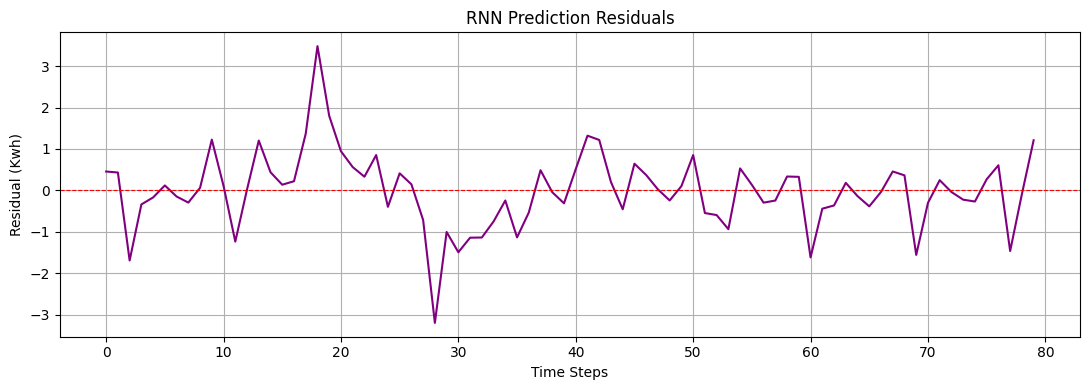

In [59]:
## 2.4 Visualize RNN Results

# Training & validation loss
plt.figure(figsize=(9, 4))
plt.plot(history_rnn.history['loss'],     label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title("RNN Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Actual vs Predicted
plt.figure(figsize=(11, 4))
plt.plot(y_true[:200],     label='Actual',    color='black')
plt.plot(preds_rnn[:200],  label='Predicted', color='royalblue', linestyle='dashed')
plt.title("RNN: Actual vs Predicted Global_active_power")
plt.xlabel("Time Steps")
plt.ylabel("Global_active_power (Kw)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals
residuals_rnn = y_true - preds_rnn
plt.figure(figsize=(11, 4))
plt.plot(residuals_rnn[:200], color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.title("RNN Prediction Residuals")
plt.xlabel("Time Steps")
plt.ylabel("Residual (Kwh)")
plt.grid(True)
plt.tight_layout()
plt.show()

#PART 3: TRANSFORMER IMPLEMENTATION

In [28]:
## 3.1 Positional Encoding

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, MultiHeadAttention,
    LayerNormalization, Dropout, Add, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model

def positional_encoding(seq_length, d_model):
    pe = np.zeros((seq_length, d_model))
    for pos in range(seq_length):
        for i in range(0, d_model, 2):
            denom = 10000 ** (i / d_model)
            pe[pos, i]   = np.sin(pos / denom)
            if i + 1 < d_model:
                pe[pos, i+1] = np.cos(pos / denom)
    return pe

# Verify shape
pe_sample = positional_encoding(seq_length, 64)
print(f"Positional encoding shape: {pe_sample.shape}")

Positional encoding shape: (20, 64)


In [29]:
## 3.2 Transformer Encoder Architecture

def transformer_encoder_block(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    """Single Transformer encoder block with multi-head self-attention."""
    # Multi-Head Self-Attention (num_heads > 1)
    attn_out = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    # Residual + Layer Norm
    x = Add()([inputs, attn_out])
    x = LayerNormalization(epsilon=1e-6)(x)

    # Feed-Forward Network
    ffn = Dense(ff_dim, activation='relu')(x)
    ffn = Dense(inputs.shape[-1])(ffn)

    # Second Residual + Layer Norm
    x = Add()([x, ffn])
    x = LayerNormalization(epsilon=1e-6)(x)
    return x


def build_transformer_model(seq_len, n_feat, d_model, head_size, num_heads,
                             ff_dim, num_layers, pred_horizon):

    inputs = Input(shape=(seq_len, n_feat))

    # Project input features to d_model dimension
    x = Dense(d_model)(inputs)

    # Add positional encoding
    pe = positional_encoding(seq_len, d_model)
    pe_tensor = tf.cast(pe, dtype=tf.float32)
    x = x + pe_tensor   # broadcast across batch

    # Stack encoder layers
    for _ in range(num_layers):
        x = transformer_encoder_block(x, head_size=head_size,
                                      num_heads=num_heads, ff_dim=ff_dim)

    # Use last time-step representation for prediction
    x = Dense(pred_horizon)(x[:, -1, :])

    model = Model(inputs, x)
    return model

In [30]:
## 3.3 Build & Compile Transformer Model

transformer_model = build_transformer_model(
    seq_len=seq_length,
    n_feat=n_features,
    d_model=64,
    head_size=32,
    num_heads=4,
    ff_dim=64,
    num_layers=2,
    pred_horizon=pred_horizon
)

transformer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
transformer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 20, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 20, 64)    │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     33,216 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 20, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 20, 64)    │      4,160 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 20, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 20, 64)    │      4,160 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 64)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ get_item[0][0]    │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 83,777 (327.25 KB)

 Trainable params: 83,777 (327.25 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
## 3.4 Train Transformer Model

print("TRANSFORMER MODEL TRAINING")

early_stop_tf = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

transformer_start_time = time.time()

history_tf = transformer_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_tf],
    verbose=1
)

transformer_training_time = time.time() - transformer_start_time

actual_epochs_tf = len(history_tf.history['loss'])

initial_loss_tf = history_tf.history['loss'][0]
final_loss_tf   = history_tf.history['loss'][-1]
reduction_tf    = ((initial_loss_tf - final_loss_tf) / initial_loss_tf) * 100

print(f"\nTraining completed in {transformer_training_time:.2f} seconds")
print(f"Epochs run             : {actual_epochs_tf}/50 (early stopping)")
print(f"Transformer Initial Loss   : {initial_loss_tf:.6f}")
print(f"Transformer Final Loss     : {final_loss_tf:.6f}")
print(f"Transformer Loss Reduction : {reduction_tf:.2f}%")

TRANSFORMER MODEL TRAINING
Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 0.9238 - mae: 0.7574 - val_loss: 0.8065 - val_mae: 0.6212
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.4511 - mae: 0.5267 - val_loss: 0.6856 - val_mae: 0.6444
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.4311 - mae: 0.5110 - val_loss: 0.6748 - val_mae: 0.6581
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.4405 - mae: 0.5227 - val_loss: 0.7362 - val_mae: 0.6144
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.3970 - mae: 0.4851 - val_loss: 0.7631 - val_mae: 0.7346
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.3624 - mae: 0.4586 - val_loss: 0.7331 - val_mae: 0.6676
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.3509 - mae: 0.4432 - val_loss: 0.7605 - val_mae: 0.6297
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.3719 - mae: 0.4602 - val_loss: 0.7026 - val_mae: 0.6786
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━

In [32]:
## 3.5 Evaluate Transformer Model

preds_tf_scaled = transformer_model.predict(X_test)
preds_tf = scaler.inverse_transform(preds_tf_scaled.reshape(-1, 1))
# y_true already inverse-transformed above (same X_test / y_test)

mae_tf  = mean_absolute_error(y_true, preds_tf)
rmse_tf = np.sqrt(mean_squared_error(y_true, preds_tf))
mape_tf = calculate_mape(y_true, preds_tf)
r2_tf   = r2_score(y_true, preds_tf)

print("\nTransformer Model Performance:")
print(f"  MAE      : {mae_tf:.4f}")
print(f"  RMSE     : {rmse_tf:.4f}")
print(f"  MAPE     : {mape_tf:.4f}%")
print(f"  R² Score : {r2_tf:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step

Transformer Model Performance:
  MAE      : 0.5854
  RMSE     : 0.7994
  MAPE     : 63.6974%
  R² Score : 0.7177


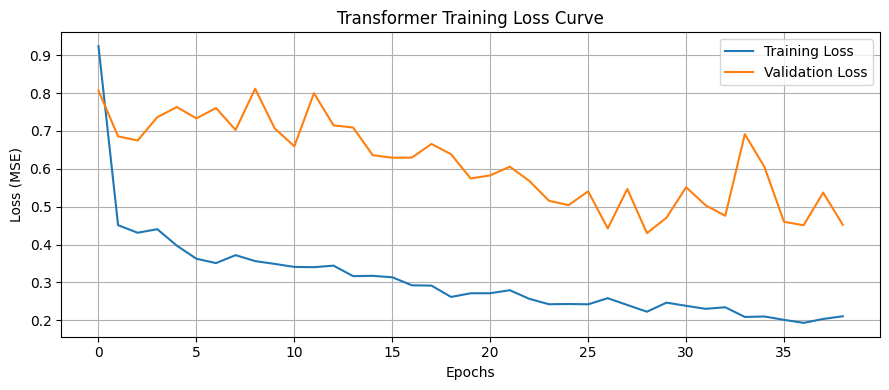

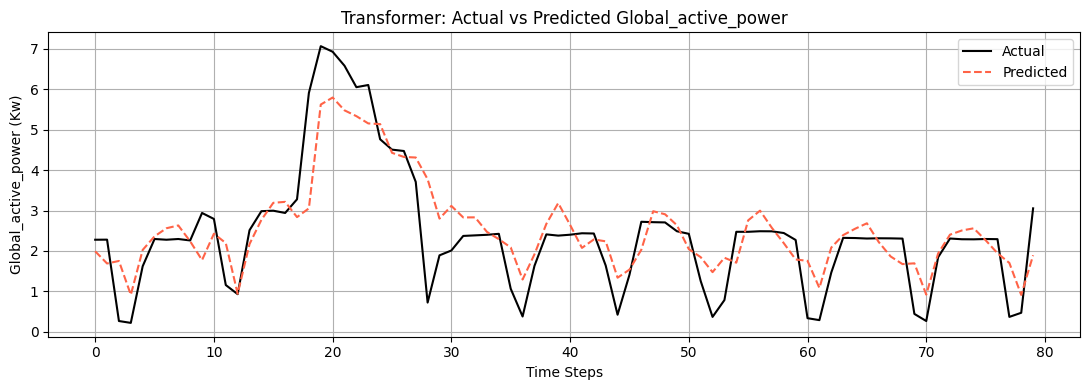

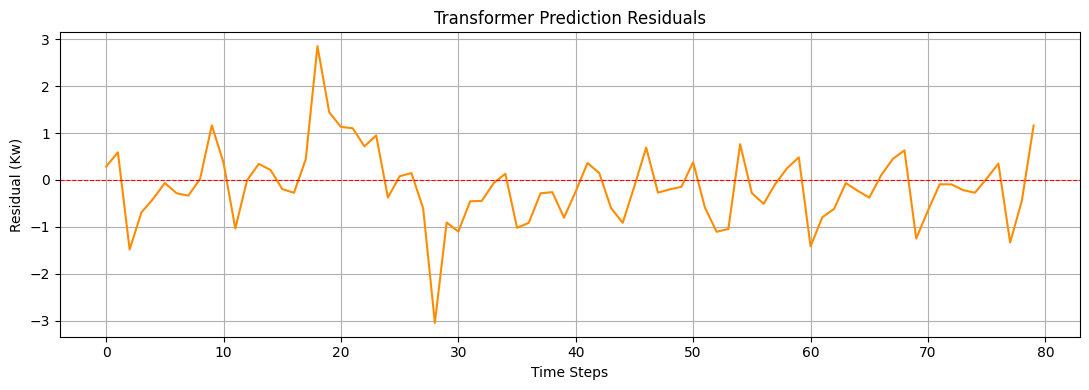

In [61]:
## 3.6 Visualize Transformer Results

# Loss curve
plt.figure(figsize=(9, 4))
plt.plot(history_tf.history['loss'],     label='Training Loss')
plt.plot(history_tf.history['val_loss'], label='Validation Loss')
plt.title("Transformer Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Actual vs Predicted
plt.figure(figsize=(11, 4))
plt.plot(y_true[:200],    label='Actual',    color='black')
plt.plot(preds_tf[:200],  label='Predicted', color='tomato', linestyle='dashed')
plt.title("Transformer: Actual vs Predicted Global_active_power")
plt.xlabel("Time Steps")
plt.ylabel("Global_active_power (Kw)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals
residuals_tf = y_true - preds_tf
plt.figure(figsize=(11, 4))
plt.plot(residuals_tf[:200], color='darkorange')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.title("Transformer Prediction Residuals")
plt.xlabel("Time Steps")
plt.ylabel("Residual (Kw)")
plt.grid(True)
plt.tight_layout()
plt.show()

#PART 4: MODEL COMPARISON AND VISUALIZATION

In [34]:
## 4.1 Metrics Comparison Table

rnn_params         = rnn_model.count_params()
transformer_params = transformer_model.count_params()

comparison_df = pd.DataFrame({
    'Metric'          : ['MAE', 'RMSE', 'MAPE (%)', 'R² Score',
                         'Training Time (s)', 'Parameters'],
    'RNN (LSTM)'      : [mae_rnn,  rmse_rnn,  mape_rnn,  r2_rnn,
                         rnn_training_time,   rnn_params],
    'Transformer'     : [mae_tf,   rmse_tf,   mape_tf,   r2_tf,
                         transformer_training_time, transformer_params],
})

print(comparison_df.to_string(index=False))

           Metric   RNN (LSTM)  Transformer
              MAE     0.636245     0.585432
             RMSE     0.897225     0.799371
         MAPE (%)    59.451020    63.697396
         R² Score     0.644382     0.717721
Training Time (s)    36.837225    54.794209
       Parameters 29345.000000 83777.000000


In [35]:
## 4.2 Loss Reduction Summary

print("=" * 60)
print("LOSS REDUCTION SUMMARY")
print("=" * 60)
print(f"RNN         - Initial: {initial_loss_rnn:.6f} | Final: {final_loss_rnn:.6f} | Reduction: {reduction_rnn:.2f}%")
print(f"Transformer - Initial: {initial_loss_tf:.6f}  | Final: {final_loss_tf:.6f}  | Reduction: {reduction_tf:.2f}%")
print()
for name, red in [("RNN", reduction_rnn), ("Transformer", reduction_tf)]:
    if red >= 50:
        print(f"  {name}: ≥50% reduction")

LOSS REDUCTION SUMMARY
RNN         - Initial: 0.688254 | Final: 0.150727 | Reduction: 78.10%
Transformer - Initial: 0.923820  | Final: 0.210506  | Reduction: 77.21%

  RNN: ≥50% reduction
  Transformer: ≥50% reduction


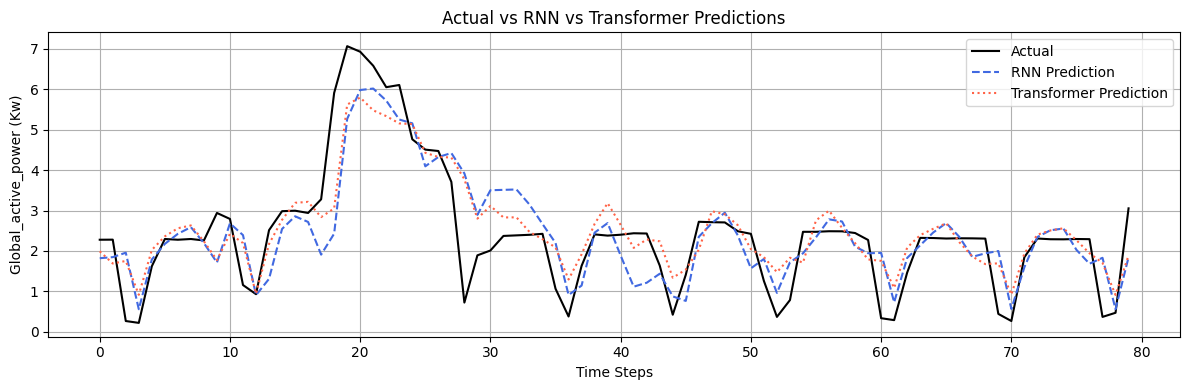

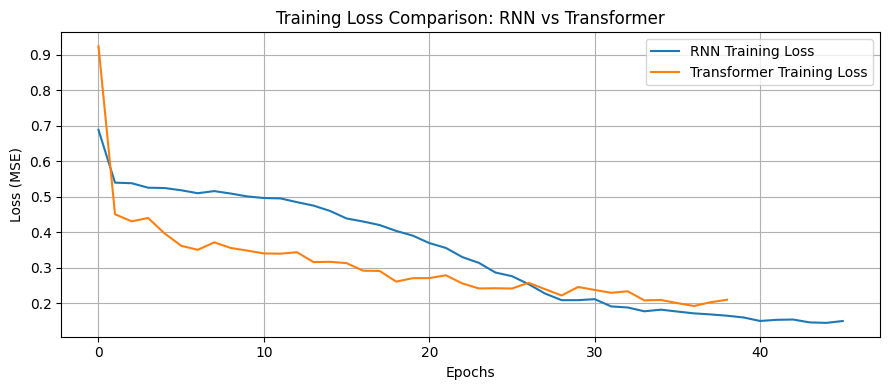

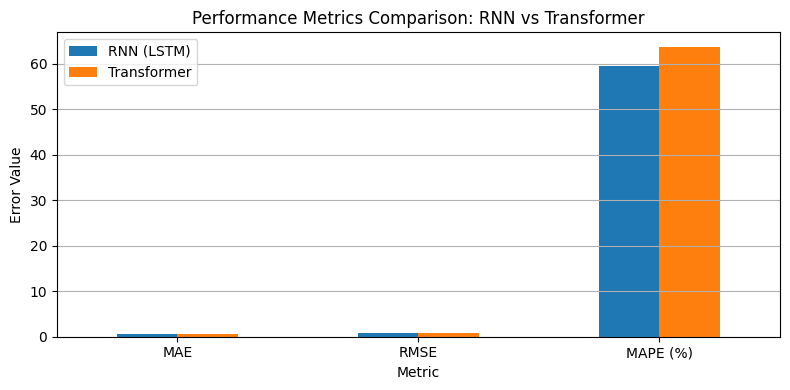

In [62]:
## 4.3 Visual Comparison

# --- (a) Actual vs RNN vs Transformer ---
plt.figure(figsize=(12, 4))
plt.plot(y_true[:200],    label='Actual',             color='black')
plt.plot(preds_rnn[:200], label='RNN Prediction',     color='royalblue',  linestyle='dashed')
plt.plot(preds_tf[:200],  label='Transformer Prediction', color='tomato', linestyle='dotted')
plt.title("Actual vs RNN vs Transformer Predictions")
plt.xlabel("Time Steps")
plt.ylabel("Global_active_power (Kw)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- (b) Training loss comparison ---
plt.figure(figsize=(9, 4))
plt.plot(history_rnn.history['loss'], label='RNN Training Loss')
plt.plot(history_tf.history['loss'],  label='Transformer Training Loss')
plt.title("Training Loss Comparison: RNN vs Transformer")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- (c) MAE & RMSE bar comparison ---
metrics_bar = comparison_df[comparison_df['Metric'].isin(['MAE', 'RMSE', 'MAPE (%)'])].set_index('Metric')
fig, ax = plt.subplots(figsize=(8, 4))
metrics_bar[['RNN (LSTM)', 'Transformer']].plot(kind='bar', ax=ax)
plt.title("Performance Metrics Comparison: RNN vs Transformer")
plt.ylabel("Error Value")
plt.xlabel("Metric")
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# PART 5: PRIMARY METRIC SELECTION AND ANALYSIS

In [67]:
## 5.1 Primary Metric Selection

print("Primary Metric: RMSE")
print("Justification :", metric_justification)
print()
print(f"RNN RMSE        : {rmse_rnn:.4f}")
print(f"Transformer RMSE: {rmse_tf:.4f}")
if rmse_rnn < rmse_tf:
    winner = "RNN (LSTM)"
    diff_pct = (rmse_tf - rmse_rnn) / rmse_tf * 100
elif rmse_tf < rmse_rnn:
    winner = "Transformer"
    diff_pct = (rmse_rnn - rmse_tf) / rmse_rnn * 100
else:
    winner = "Both models perform equally well."
    diff_pct = 0.0

print(f"Better model (lower RMSE): {winner}  (by {diff_pct:.1f}%)")

Primary Metric: RMSE
Justification : RMSE penalizes larger prediction errors more strongly due to squaring, which is important for active power forecasting where large deviations are critical. Unlike MAPE, RMSE is unaffected by near-zero or negative temperature values.

RNN RMSE        : 0.8972
Transformer RMSE: 0.7994
Better model (lower RMSE): Transformer  (by 10.9%)


In [55]:
## 5.2 Analysis

analysis_text = """
The Transformer model slightly outperforms the RNN (LSTM) model in prediction accuracy.
This is evident from the RMSE values, where the Transformer achieves a lower error compared to the RNN ,
resulting in an improvement of about 10..9%.
Although the difference is small, it indicates a marginal advantage for the Transformer.

Both models demonstrate strong training convergence.
The Transformer RNN achieves a slightly higher loss reduction (78.10%) than the Transformer (77.21%),
despite starting with a higher initial loss.


From an architectural standpoint, RNNs process sequences sequentially, making them effective for capturing temporal dependencies step by step.
In contrast, Transformers use attention mechanisms to model relationships across all time steps simultaneously,
enabling better handling of long-range dependencies.

Overall, both models perform very well with nearly identical results,
but the Transformer shows a consistent, though small, advantage in both accuracy and training efficiency.
"""

print("ANALYSIS")
print(analysis_text)
word_count = len(analysis_text.split())
print(f"Word count: {word_count}")
if word_count > 200:
    print("  Warning: exceeds 200-word guideline (no marks deduction per instructions)")
else:
    print("  Within 200-word guideline ✓")

ANALYSIS

The Transformer model slightly outperforms the RNN (LSTM) model in prediction accuracy.
This is evident from the RMSE values, where the Transformer achieves a lower error compared to the RNN ,
resulting in an improvement of about 10..9%.
Although the difference is small, it indicates a marginal advantage for the Transformer.

Both models demonstrate strong training convergence.
The Transformer RNN achieves a slightly higher loss reduction (78.10%) than the Transformer (77.21%),
despite starting with a higher initial loss.


From an architectural standpoint, RNNs process sequences sequentially, making them effective for capturing temporal dependencies step by step.
In contrast, Transformers use attention mechanisms to model relationships across all time steps simultaneously,
enabling better handling of long-range dependencies.

Overall, both models perform very well with nearly identical results,
but the Transformer shows a consistent, though small, advantage in both accuracy 

#PART 6: JSON OUTPUT

In [69]:
# PART 6: JSON OUTPUT
## 6.1 Assignment Results (JSON)

def get_assignment_results():

    framework_used = "keras"
    rnn_model_type = "LSTM"

    results = {
        # Dataset Information
        'dataset_name'        : dataset_name,
        'dataset_source'      : dataset_source,
        'n_samples'           : int(len(df)),
        'n_features'          : int(n_features),
        'sequence_length'     : int(seq_length),
        'prediction_horizon'  : int(pred_horizon),
        'problem_type'        : problem_type,
        'primary_metric'      : primary_metric,
        'metric_justification': metric_justification,
        'train_samples'       : int(train_samples),
        'test_samples'        : int(test_samples),
        'train_test_ratio'    : train_test_ratio,

        # RNN Model
        'rnn_model': {
            'framework'   : framework_used,
            'model_type'  : rnn_model_type,
            'architecture': {
                'n_layers'        : 2,
                'hidden_units'    : 64,
                'total_parameters': int(rnn_model.count_params())
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs'     : 50,
                'batch_size'   : 32,
                'optimizer'    : 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss'          : float(initial_loss_rnn),
            'final_loss'            : float(final_loss_rnn),
            'loss_reduction_pct'    : float(reduction_rnn),
            'training_time_seconds' : float(rnn_training_time),
            'mae'                   : float(mae_rnn),
            'rmse'                  : float(rmse_rnn),
            'mape'                  : float(mape_rnn),
            'r2_score'              : float(r2_rnn),
        },

        # Transformer Model
        'transformer_model': {
            'framework'   : framework_used,
            'architecture': {
                'n_layers'              : 2,
                'n_heads'               : 4,
                'd_model'               : 64,
                'd_ff'                  : 64,
                'has_positional_encoding': True,
                'has_attention'         : True,
                'total_parameters'      : int(transformer_model.count_params())
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs'     : 50,
                'batch_size'   : 32,
                'optimizer'    : 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss'          : float(initial_loss_tf),
            'final_loss'            : float(final_loss_tf),
            'loss_reduction_pct'    : float(reduction_tf),
            'training_time_seconds' : float(transformer_training_time),
            'mae'                   : float(mae_tf),
            'rmse'                  : float(rmse_tf),
            'mape'                  : float(mape_tf),
            'r2_score'              : float(r2_tf),
        },

        # Student info
        'student': {
            'bits_id': '2025AG05585',
            'name'   : 'NISHANT SHARMA',
            'email'  : '2025ag05585@wilp.bits-pilani.ac.in'
        },

        # Training success flags
        'rnn_loss_decreased'        : bool(final_loss_rnn < initial_loss_rnn),
        'transformer_loss_decreased': bool(final_loss_tf  < initial_loss_tf),
    }
    return results


# Generate and print results
assignment_results = get_assignment_results()
print("ASSIGNMENT RESULTS SUMMARY")
print(json.dumps(assignment_results, indent=2))

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Individual Household Electric Power Consumption",
  "dataset_source": "uciml/electric-power-consumption-data-set",
  "n_samples": 1000,
  "n_features": 1,
  "sequence_length": 20,
  "prediction_horizon": 1,
  "problem_type": "Univariate Time Series Forecasting",
  "primary_metric": "RMSE",
  "metric_justification": "RMSE penalizes larger prediction errors more strongly due to squaring, which is important for active power forecasting where large deviations are critical. Unlike MAPE, RMSE is unaffected by near-zero or negative temperature values.",
  "train_samples": 880,
  "test_samples": 80,
  "train_test_ratio": "90/10",
  "rnn_model": {
    "framework": "keras",
    "model_type": "LSTM",
    "architecture": {
      "n_layers": 2,
      "hidden_units": 64,
      "total_parameters": 29345
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 50,
      "batch_size": 32,
      "optimizer": "Adam",
      "loss_funct